<img src="./logo_UTN.svg" align="right" width="150" />

# Tarea Semanal 7

*Alumno: Lapilli Cañedo, Mariano Adrian*

# Consigna

Dado el siguiente esquema:

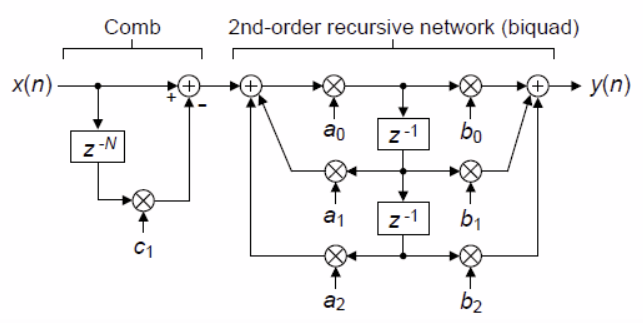

Se pide:

1. Comprobar que el esquema se corresponde con la siguiente transferencia:
   $H(z) = (1 - c_1 z^{N}) \frac{b_0 + b_1 z^{-1} + b_2 z^{-2} }{\frac{1}{a_0} + a_1 z^{-1} + a_2 z^{-2}} $
2. Filtro de **media móvil** (moving average ó CIC: cascaded integrator comb)
    - Verificar la transferencia para $a_0$= 1, $a_1$= 1, $b_0$= 1/*N* , $c_1$= 1 y *N* = 3, 4 y 5.
    - ¿Es un filtro IIR o FIR ? Discuta las ventajas que tendría esta implementación respecto al filtro FIR de media móvil 3.
    - ¿Podría implementar el siguiente sistema $h_{(k)}$ = (1, 1, 1, 1, 1, 1, 1) con esta topología ?
3. Filtro diferenciador ( differentiator )
    - Obtener los valores de $a_i$ y $b_k$ para obtener $y_{(n)} = [x_{(n)} - x_{(n - 2)}] $ / 2
    - Evaluar al sistema con un seno discreto en python y comprobar si la salida se aproxima a la derivada.

4. Filtro elimina continua ( DC Blocker )

    - Verifique la transferencia para $a_0$= 1, $a_1$= $\beta$, $b_0$= 1 , $b_1$= -1 para $\beta$ = 0.9.

    - Determine $\beta$ para que la transferencia en $\Omega$ = 0.1 $\pi$ sea 3 dB menor a la transferencia en  $\Omega$ = $\pi$.
 
5. Filtro Peine  ( Comb filter )

    - Verifique la transferencia para $c_1$ = -1 y  $N$ = 8
 
    - Proponga una $f_{sampling}$ y halle las frecuencias donde se generan los peaks y los nulls en el espectro.

Importante: Para los siguientes incisos calcular y representar sus singularidades en el plano $z$, su Respuesta de módulo y fase de  $H_{(z)}$ y su diagrama en bloques. Cuando no se indique considerar los coeficientes igual a cero.


# Bonus

- 🥉 Verificar en Python el punto 3) con la función diff 
- 🥉 Utilizando solo el biquad, hallar los valores de los coeficientes para emular la respuesta analógica de un pasatodo de orden 1. Utilice alguno de los métodos de diseño vistos en clases. 
- 🥉 Completar el siguiente cuestionario


In [2]:
# Importo librerias de python para trabajar

import numpy as np
from scipy import signal as sig
import sympy as sp
import control as ct
from matplotlib import pyplot as plt
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys
from pytc2.sistemas_lineales import pretty_print_lti
from pytc2.general import print_latex, a_equal_b_latex_s
from pytc2.cuadripolos import calc_MAI_ztransf_ij_mn
from pytc2.cuadripolos import calc_MAI_vtransf_ij_mn
import sympy as sp
import control.matlab as ctl

# Resolución

# Item 1

Resolución hecha en el pizarrón:

# Item 2

In [3]:
z, c1, b0, b1, b2, a0, a1, a2, N, s, Ts = sp.symbols("z c1 b0 b1 b2 a0 a1 a2 N s Ts", real=True, positive=True)


H = (1 - c1 * z**N) * (b0 + b1 * z**(-1) + b2 * z**(-2)) / ((1 / a0) - a1 * z**(-1) - a2 * z**(-2))

print_latex(a_equal_b_latex_s('H(z)', H))

<IPython.core.display.Math object>

Esta es la transferencia genérica obtenida a través del diagrama en bloque, ahora vamos a obtener los distintos casos que se solicitan en la consigna

### Filtro de Media Móvil

Parámetros:  $a_0$= 1, $a_1$= 1, $b_0$= 1/*N* , $c_1$= 1 y *N* = 3, 4 y 5.

In [4]:
# Considero los coeficientes restantes como nulos.

a0 = 1
a1 = 1
a2 = 0
c1 = 1
N = 3
b0 = 1/N
b1 = 0
b2 = 0

H3 = (1 - c1 * z**(-N)) * (b0 + b1 * z**(-1) + b2 * z**(-2)) / ((1 / a0) - a1 * z**(-1) - a2 * z**(-2))

print ("-" * 50)
print_latex ("Para \ N = 3 :")
print_latex(a_equal_b_latex_s('H(z)', H3))

N = 4 
b0 = 1/N

H4 = (1 - c1 * z**(-N)) * (b0 + b1 * z**(-1) + b2 * z**(-2)) / ((1 / a0) - a1 * z**(-1) - a2 * z**(-2))

print ("-" * 50)
print_latex ("Para \ N = 4 :")
print_latex(a_equal_b_latex_s('H(z)', H4))

N = 5 
b0 = 1/N

H5 = (1 - c1 * z**(-N)) * (b0 + b1 * z**(-1) + b2 * z**(-2)) / ((1 / a0) - a1 * z**(-1) - a2 * z**(-2))

print ("-" * 50)
print_latex ("Para \ N = 5 :")
print_latex(a_equal_b_latex_s('H(z)', H5))
print ("-" * 50)


--------------------------------------------------


<IPython.core.display.Math object>

<IPython.core.display.Math object>

--------------------------------------------------


<IPython.core.display.Math object>

<IPython.core.display.Math object>

--------------------------------------------------


<IPython.core.display.Math object>

<IPython.core.display.Math object>

--------------------------------------------------


Vamos a analizar los polos y ceros de la transferencia de N = 3:

/home/mariano/marianoTC2/lib/python3.12/site-packages/scipy/signal/_filter_design.py:565: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/home/mariano/marianoTC2/lib/python3.12/site-packages/control/pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


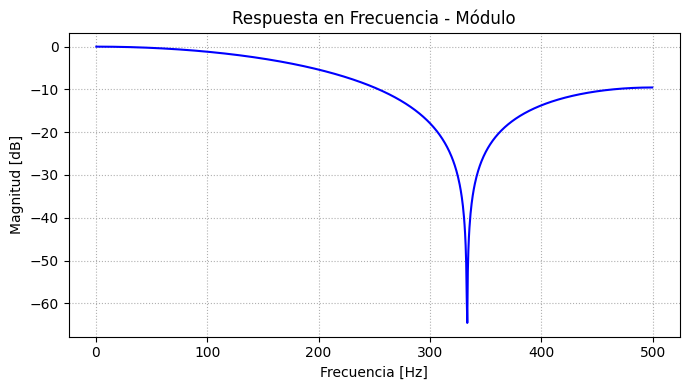

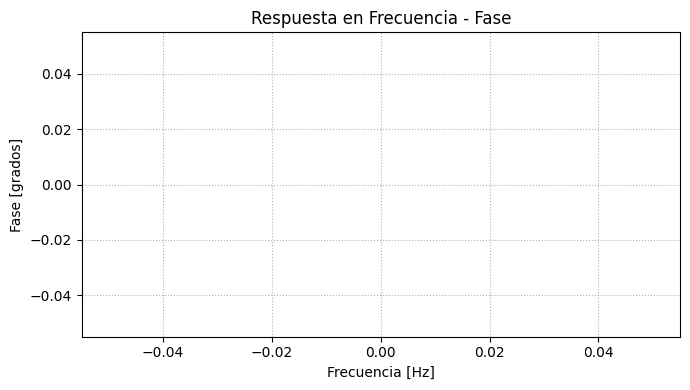

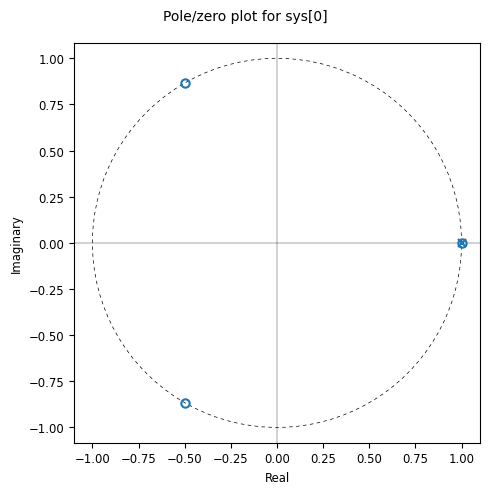

In [5]:
num = [1/3, 0, 0, -1/3]
den = [1, -1]

fs = 1000  # Frecuencia de muestreo (Hz)
dt = 1.0 / fs  # Período de muestreo

# 2. Cálculos de frecuencia para módulo y fase
w, h = sig.freqz(num, den, worN=1024, fs=fs)
modulo_db = 20 * np.log10(np.abs(h) + 1e-12)
fase_deg = np.unwrap(np.angle(h)) * (180 / np.pi)

# ==========================================
# Ventana 1: Módulo
# ==========================================
plt.figure(figsize=(7, 4))
plt.plot(w, modulo_db, color="b", linewidth=1.5)
plt.title("Respuesta en Frecuencia - Módulo")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.grid(True, linestyle=":")
plt.tight_layout()

# ==========================================
# Ventana 2: Fase
# ==========================================
plt.figure(figsize=(7, 4))
plt.plot(w, fase_deg, color="r", linewidth=1.5)
plt.title("Respuesta en Frecuencia - Fase")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [grados]")
plt.grid(True, linestyle=":")
plt.tight_layout()

# ==========================================
# Ventana 3: Polos y Ceros con pzmap
# ==========================================
plt.figure(figsize=(5, 5))

# Se crea la función de transferencia discreta especificando dt
H = ctl.tf(num, den, 1)

# pzmap traza automáticamente el círculo unitario y los polos/ceros
ctl.pzmap(H)
plt.tight_layout()

plt.show()

Como se puede observar, un polo queda cancelado por un cero, por lo que se puede decir que son filtros FIR. Una gran ventaja es que son fáciles de implementar y ayudan a "suavizar" las señales de alta frecuencia y ruido.

Implementación $h_{(k)}$ = (1, 1, 1, 1, 1, 1, 1):

Es posible, ya que depende de 7 muestras, es decir $N$ = 7 y para lograr respuestas unitarias el factor de escala de $b_0$ debe ser unitario también

In [6]:
a0 = 1
a1 = 1
a2 = 0
c1 = 1
N = 7
b0 = 1
b1 = 0
b2 = 0

H3 = (1 - c1 * z**(-N)) * (b0 + b1 * z**(-1) + b2 * z**(-2)) / ((1 / a0) - a1 * z**(-1) - a2 * z**(-2))

print ("-" * 50)
print_latex ("Para \ implementación \ h(k) :")
print_latex(a_equal_b_latex_s('H(z)', H3))
print ("-" * 50)

--------------------------------------------------


<IPython.core.display.Math object>

<IPython.core.display.Math object>

--------------------------------------------------


/home/mariano/marianoTC2/lib/python3.12/site-packages/scipy/signal/_filter_design.py:565: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/home/mariano/marianoTC2/lib/python3.12/site-packages/control/pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


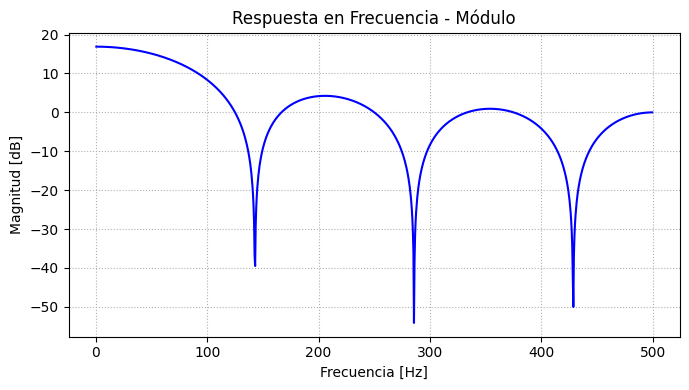

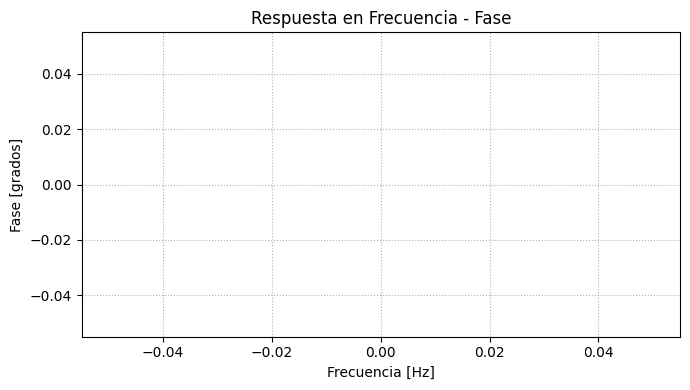

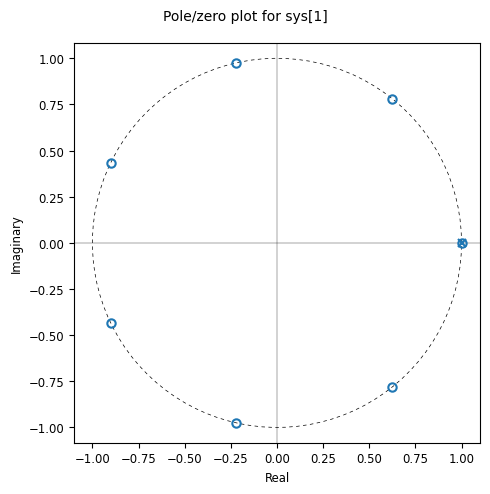

In [7]:
num = [1, 0, 0, 0, 0, 0, 0, -1]
den = [1, -1]

fs = 1000  # Frecuencia de muestreo (Hz)
dt = 1.0 / fs  # Período de muestreo

# 2. Cálculos de frecuencia para módulo y fase
w, h = sig.freqz(num, den, worN=1024, fs=fs)
modulo_db = 20 * np.log10(np.abs(h) + 1e-12)
fase_deg = np.unwrap(np.angle(h)) * (180 / np.pi)

# ==========================================
# Ventana 1: Módulo
# ==========================================
plt.figure(figsize=(7, 4))
plt.plot(w, modulo_db, color="b", linewidth=1.5)
plt.title("Respuesta en Frecuencia - Módulo")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.grid(True, linestyle=":")
plt.tight_layout()

# ==========================================
# Ventana 2: Fase
# ==========================================
plt.figure(figsize=(7, 4))
plt.plot(w, fase_deg, color="r", linewidth=1.5)
plt.title("Respuesta en Frecuencia - Fase")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [grados]")
plt.grid(True, linestyle=":")
plt.tight_layout()

# ==========================================
# Ventana 3: Polos y Ceros con pzmap
# ==========================================
plt.figure(figsize=(5, 5))

# Se crea la función de transferencia discreta especificando dt
H = ctl.tf(num, den, 1)

# pzmap traza automáticamente el círculo unitario y los polos/ceros
ctl.pzmap(H)
plt.tight_layout()

plt.show()

### Filtro diferenciador

Llevo la expresión $y(n) = [x(n) - x(n-2)] / 2 $ al dominio de Z

$$ Y(Z) = \frac{X(Z) - X(Z) Z^{-2} }{2} \rightarrow H(Z) = \frac{1 -  Z^{-2} }{2}$$

Con esto llegamos a la conclusión de que:

In [8]:
a0 = 0.5
a1 = 0
a2 = 0
c1 = 0
N = 0
b0 = 1
b1 = 0
b2 = - 1

H = (1 - c1 * z**(-N)) * (b0 + b1 * z**(-1) + b2 * z**(-2)) / ((1 / a0) - a1 * z**(-1) - a2 * z**(-2))

print ("-" * 50)
print_latex ("Diferenciador :")
print_latex(a_equal_b_latex_s('H(z)', H))
print ("-" * 50)

--------------------------------------------------


<IPython.core.display.Math object>

<IPython.core.display.Math object>

--------------------------------------------------


/home/mariano/marianoTC2/lib/python3.12/site-packages/control/pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


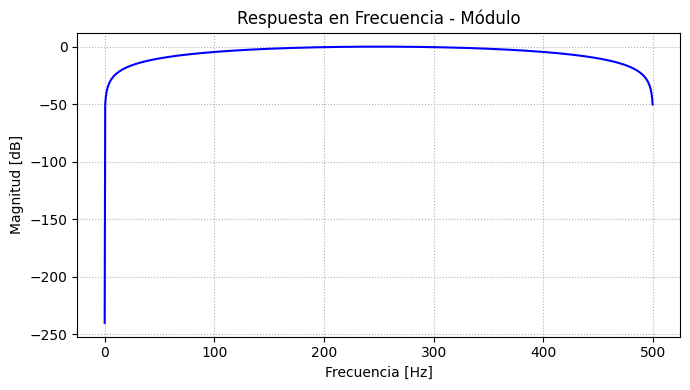

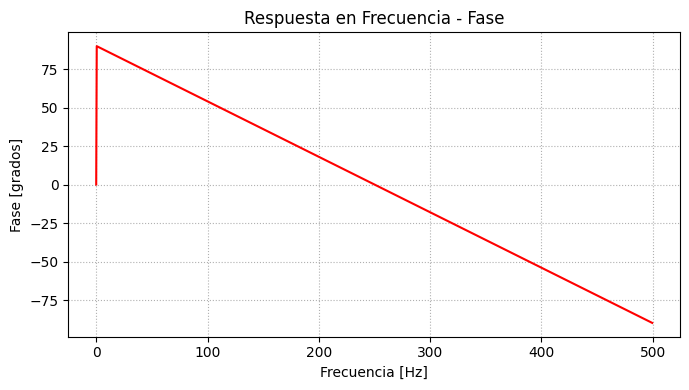

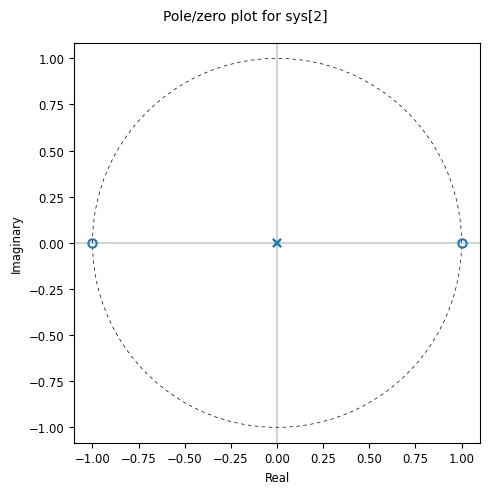

In [9]:
num = [0.5, 0.0, -0.5]  # [b0, b1, b2]
den = [1, 0, 0]             # [a0]

fs = 1000  # Frecuencia de muestreo (Hz)
dt = 1.0 / fs  # Período de muestreo

# 2. Cálculos de frecuencia para módulo y fase
w, h = sig.freqz(num, den, worN=1024, fs=fs)
modulo_db = 20 * np.log10(np.abs(h) + 1e-12)
fase_deg = np.unwrap(np.angle(h)) * (180 / np.pi)

# ==========================================
# Ventana 1: Módulo
# ==========================================
plt.figure(figsize=(7, 4))
plt.plot(w, modulo_db, color="b", linewidth=1.5)
plt.title("Respuesta en Frecuencia - Módulo")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.grid(True, linestyle=":")
plt.tight_layout()

# ==========================================
# Ventana 2: Fase
# ==========================================
plt.figure(figsize=(7, 4))
plt.plot(w, fase_deg, color="r", linewidth=1.5)
plt.title("Respuesta en Frecuencia - Fase")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [grados]")
plt.grid(True, linestyle=":")
plt.tight_layout()

# ==========================================
# Ventana 3: Polos y Ceros con pzmap
# ==========================================
plt.figure(figsize=(5, 5))

# Se crea la función de transferencia discreta especificando dt
H = ctl.tf(num, den, 1)

# pzmap traza automáticamente el círculo unitario y los polos/ceros
ctl.pzmap(H)
plt.tight_layout()

plt.show()

Como vemos, se aproxima a un derivador.

### Filtro elimina continua

In [10]:
beta = 0.9
a0 = 1
a1 = beta
a2 = 0
c1 = 0
N = 0
b0 = 1
b1 = 0
b2 = - 1

H = (1 - c1 * z**(-N)) * (b0 + b1 * z**(-1) + b2 * z**(-2)) / ((1 / a0) - a1 * z**(-1) - a2 * z**(-2))

print ("-" * 50)
print_latex ("Elimina \ continua :")
print_latex(a_equal_b_latex_s('H(z)', H))
print ("-" * 50)

--------------------------------------------------


<IPython.core.display.Math object>

<IPython.core.display.Math object>

--------------------------------------------------


/home/mariano/marianoTC2/lib/python3.12/site-packages/control/pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


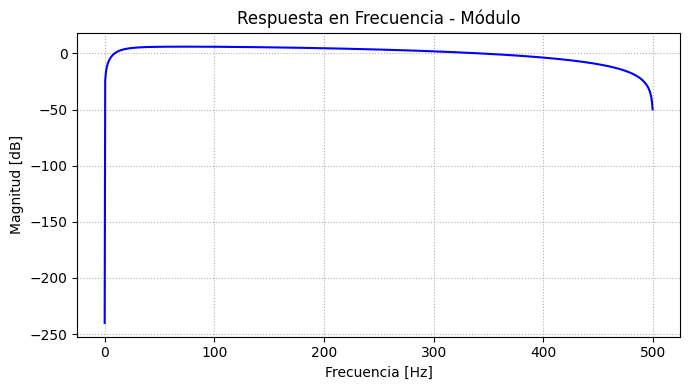

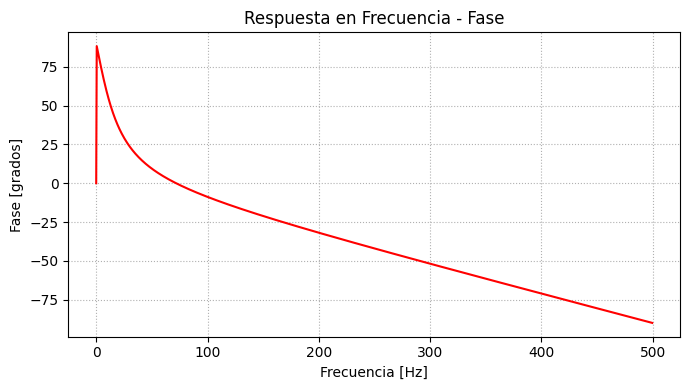

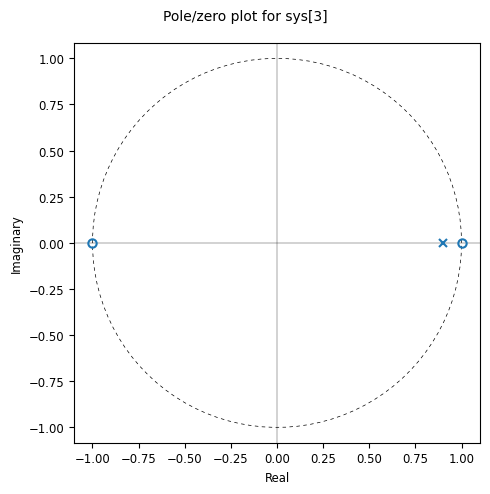

In [11]:
num = [1, 0, -1]
den = [1, -0.9]

fs = 1000  # Frecuencia de muestreo (Hz)
dt = 1.0 / fs  # Período de muestreo

# 2. Cálculos de frecuencia para módulo y fase
w, h = sig.freqz(num, den, worN=1024, fs=fs)
modulo_db = 20 * np.log10(np.abs(h) + 1e-12)
fase_deg = np.unwrap(np.angle(h)) * (180 / np.pi)

# ==========================================
# Ventana 1: Módulo
# ==========================================
plt.figure(figsize=(7, 4))
plt.plot(w, modulo_db, color="b", linewidth=1.5)
plt.title("Respuesta en Frecuencia - Módulo")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.grid(True, linestyle=":")
plt.tight_layout()

# ==========================================
# Ventana 2: Fase
# ==========================================
plt.figure(figsize=(7, 4))
plt.plot(w, fase_deg, color="r", linewidth=1.5)
plt.title("Respuesta en Frecuencia - Fase")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [grados]")
plt.grid(True, linestyle=":")
plt.tight_layout()

# ==========================================
# Ventana 3: Polos y Ceros con pzmap
# ==========================================
plt.figure(figsize=(5, 5))

# Se crea la función de transferencia discreta especificando dt
H = ctl.tf(num, den, 1)

# pzmap traza automáticamente el círculo unitario y los polos/ceros
ctl.pzmap(H)
plt.tight_layout()

plt.show()

Para los parámetros dados:

$$H(z) = \frac{z - 1}{z - \beta}$$

Reemplazo $z$ por $e^{j \Omega}$:

$$|H(\Omega)|^{2} = |\frac{e^{j\Omega} - 1}{e^{j\Omega} - \beta}| = |\frac{(cos\Omega - 1)^2 + sen^{2}\Omega}{(cos\Omega - \beta)^2 + sen^{2}\Omega}|  = \frac{2 - 2 cos \Omega}{1 + \beta^{2} - 2 \beta cos\Omega}$$

Para $\Omega$ = $\pi$:

$$|H(\pi)|^{2} =\frac{4}{(1 + \beta)^2} \rightarrow |H(\pi)| = \frac{2}{1 + \beta}$$

Para $\Omega$ = 0.1 $\pi$, que sea 3dB menor se puede decir que la potencia cae a la mitad:

$$|H(0.1 \pi)|^{2} = \frac{1}{2} |H(\pi)|^{2}  = \frac{1}{2} \frac{4}{(1 + \beta)^2} = \frac{2}{1 + \beta}$$

Igualo la expresión general a la obtenida

$$\frac{1 - cos(0.1 \pi)}{1 + \beta^2 - 2 \beta cos(0.1 \pi)} = \frac{1}{(1 + \beta)^2}$$

Operando (lo hice con la calculadora) llegamos a que $\beta$ = $0.726$

### Filtro Peine

In [12]:
beta = 0
a0 = 1
a1 = 0
a2 = 0
c1 = -1
N = 8
b0 = 1
b1 = 0
b2 = 0

H = (1 - c1 * z**(-N)) * (b0 + b1 * z**(-1) + b2 * z**(-2)) / ((1 / a0) - a1 * z**(-1) - a2 * z**(-2))

print ("-" * 50)
print_latex ("Filtro \ peine :")
print_latex(a_equal_b_latex_s('H(z)', H))
print ("-" * 50)

--------------------------------------------------


<IPython.core.display.Math object>

<IPython.core.display.Math object>

--------------------------------------------------


/home/mariano/marianoTC2/lib/python3.12/site-packages/control/pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


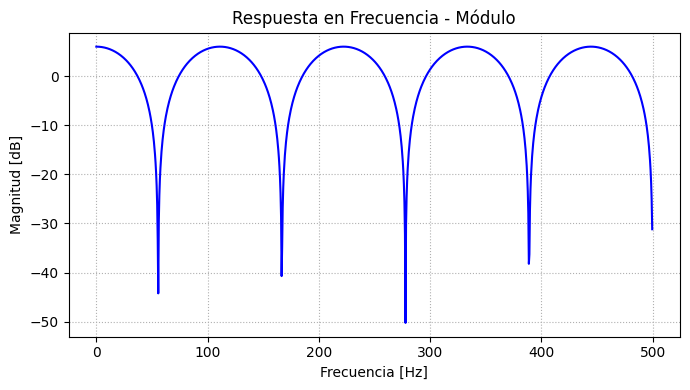

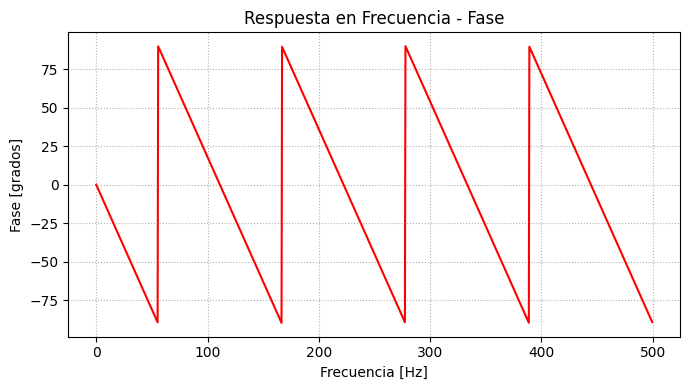

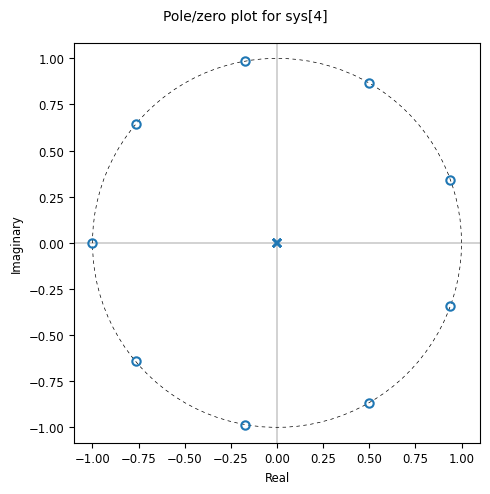

In [13]:
num = [1, 0, 0, 0, 0, 0, 0, 0, 0, 1]
den = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]

fs = 1000  # Frecuencia de muestreo (Hz)
dt = 1.0 / fs  # Período de muestreo

# 2. Cálculos de frecuencia para módulo y fase
w, h = sig.freqz(num, den, worN=1024, fs=fs)
modulo_db = 20 * np.log10(np.abs(h) + 1e-12)
fase_deg = np.unwrap(np.angle(h)) * (180 / np.pi)

# ==========================================
# Ventana 1: Módulo
# ==========================================
plt.figure(figsize=(7, 4))
plt.plot(w, modulo_db, color="b", linewidth=1.5)
plt.title("Respuesta en Frecuencia - Módulo")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.grid(True, linestyle=":")
plt.tight_layout()

# ==========================================
# Ventana 2: Fase
# ==========================================
plt.figure(figsize=(7, 4))
plt.plot(w, fase_deg, color="r", linewidth=1.5)
plt.title("Respuesta en Frecuencia - Fase")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [grados]")
plt.grid(True, linestyle=":")
plt.tight_layout()

# ==========================================
# Ventana 3: Polos y Ceros con pzmap
# ==========================================
plt.figure(figsize=(5, 5))

# Se crea la función de transferencia discreta especificando dt
H = ctl.tf(num, den, 1)

# pzmap traza automáticamente el círculo unitario y los polos/ceros
ctl.pzmap(H)
plt.tight_layout()

plt.show()

Reescribo $H(z)$ como $H(e^{j\Omega})$

$$H(e^{j\Omega}) = 2 cos(4\Omega) e^{-j4\Omega}$$

Propongo una $f_{sampling}$ de 8 kHz, el intervalo de la señal es [0, $f_s /2$] = [0, 4 kHz]

La $\Omega$ de picos se da cuando el coseno es unitario osea que $\Omega = \frac{k \pi}{4}$ y la de nulos es $\Omega = \frac{(2k + 1) \pi}{8}$

Reemplazando obtuve que:

Las frecuencias de Máximos son:

$f_0 = 0 Hz$

$f_1 = 1 kHz$

$f_2 = 2 kHz$

$f_3 = 3 kHz$

$f_4 = 4 kHz$

Las frecuencias de Mínimas son:

$f_0 = 500 Hz$

$f_1 = 1.5 kHz$

$f_2 = 2.5 kHz$

$f_3 = 3.5 kHz$
 

## Bonus

El punto 3 ya está chequeado.

PASA TODO de primer orden

$$H(s) = \frac{s - 1}{ s + 1}$$

Aplicando la transformada bilineal: $s = \frac{2}{T_s} \frac{1 - z^{-1}}{1 + z^{-1}}$

In [14]:
s = (2)/(Ts) * (1 - z**(-1)) / (1 + z**(-1))

H = (s - 1) / (s + 1)

H_simplificada = sp.cancel(H)

H_factorizada = sp.collect(H_simplificada, z)

print ("-" * 50)
print_latex ("Filtro \ pasa \ todo :")
print_latex(a_equal_b_latex_s('H(z)', H_factorizada))
print ("-" * 50)


--------------------------------------------------


<IPython.core.display.Math object>

<IPython.core.display.Math object>

--------------------------------------------------


Con esto, llego a que:

b2 = 0

b1 = -(Ts + 2)

b0 = (2 - TS)

a2 = 0

a1 = (Ts - 2)

a0 = (Ts + 2)
